# Atom Feature Vector

## What Problem Are We Actually Solving?

A neural network only understand numbers. It can't read "this atom is Carbon" or "these two atom are bonded." So your job, before any ML happens, is to translate molecule into pure math.

A molecule has two things: 
- **Atoms** (What type they are)
- **Bonds** (Which atoms are connected)

You need to encode both as matrices of numbers

## Part 1: The Feature Vector (encoding ONE atom)

Take Carbon. How do you turn "Carbon" into a number?

The naive way: assign C=1, N=2, O=3, H=4. But that's wrong — it implies Carbon is "less than" Nitrogen, or that H is "4 times" Carbon. These atoms aren't ordered or scaled. They're just different categories.

The correct way is one-hot encoding. You decide on a fixed list of atom types:
```
[C, N, O, H]
```

The correct way is one-hot encoding. You decide on a fixed list of atom types:

```
Carbon   → [1, 0, 0, 0]
Nitrogen → [0, 1, 0, 0]
Oxygen   → [0, 0, 1, 0]
Hydrogen → [0, 0, 0, 1]
```

That vector — `[1, 0, 0, 0]` for Carbon — is the feature vector for that one atom. It's just a way of saying "this atom is Carbon and nothing else."


## Part 2: The Feature Matrix (encoding ALL atoms)

A molecule has multiple atoms. So you stack all their feature vectors into a table — one row per atom.
Water (H₂O) has 3 atoms: O, H, H. So its feature matrix is:

```
        C  N  O  H
atom0: [0, 0, 1, 0]   ← Oxygen
atom1: [0, 0, 0, 1]   ← Hydrogen
atom2: [0, 0, 0, 1]   ← Hydrogen
```
This is a 3×4 matrix. The GNN will use each row as the starting "identity" of each atom before any learning happens.

## Part 3: The Adjacency Matrix (encoding bonds)

Now you need to encode _which atoms are connected._ You make a square matrix -- rows and columns are both atoms, and you put a 1 wherever there's bond.

Water: atom_0 = O, atom_1 = H, Oxygen is bonded to both hydrogens. The Hydrogens aren't bonded to each other. 

```
        atom0  atom1  atom2
atom0:  [ 0,    1,     1  ]   ← O bonds to H and H
atom1:  [ 1,    0,     0  ]   ← H bonds to O
atom2:  [ 1,    0,     0  ]   ← H bonds to O
```
This is a 3×3 matrix. Notice it's symmetric — if O is bonded to H, then H is bonded to O. Bonds go both ways.
The diagonal is 0 — an atom is not "bonded to itself."

## What we are building today 

A function that takes a **SMILES** string (like `"O"` for water or `"CCO"` for ethanol) and outputs two numpy arrays:

1. Feature matrix — shape `(n_atoms, 4)` — who each atom is
2. Adjacency matrix — shape `(n_atoms, n_atoms)` — who each atom is connected to

In [71]:
# Step 1: Import numpy & RDKit `Chem` module
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw

In [72]:
# Step 2: Define your atom type list

ATOM_TYPES = ["C", "N", "O", "H", "F", "Cl", "Br", "S", "P"]

In [73]:
"""
Step 3: Write a function `one_hot(atom_sympol, atom_type) that:
    - Make a list of zeros with lenght = number of atom types
    - Finds the index of `atom_symbol` in `atom_types`
    - Set that index to 1
    - Return the list
"""


def one_hot(atom_symbol: str, atom_types: list) -> np.ndarray:
    """
    One-hot encode a single atom.
    Unknown atoms get a zero vector (safe fallback instead of crashing).

    Returns: np.ndarray of shape (len(atom_types),)
    """
    vec = np.zeros(len(atom_types))
    if atom_symbol in atom_types:
        vec[atom_types.index(atom_symbol)] = 1
    # if unknown → stays all zeros (you'll know something is wrong)
    return vec

In [74]:
"""
Step 4. Write a function mol_to_graph(smiles) that:
    - Calls Chem.MolFromSmiles(smiles) to parse the SMILES into a molecule object
    - Calls Chem.AddHs(mol) — RDKit hides hydrogens by default, you want them explicit
    - Loops over mol.GetAtoms() — each atom has a .GetSymbol() method returning "C", "O", etc. — call your one_hot function on each and collect them into a list, then convert to a numpy array. That's your feature matrix.
    - Gets n_atoms = mol.GetNumAtoms() and creates a (n_atoms, n_atoms) numpy zeros matrix
    - Loops over mol.GetBonds() — each bond has .GetBeginAtomIdx() and .GetEndAtomIdx() — set both [i][j] and [j][i] to 1 in your adjacency matrix
    - Returns both matrices
"""


def mol_to_graph(smiles: str) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """
    Convert a SMILES string into a graph representation.

    Returns:
        feature_matrix : np.ndarray, shape (n_atoms, len(ATOM_TYPES))
                         Row i = one-hot vector for atom i
        adj_matrix     : np.ndarray, shape (n_atoms, n_atoms)
                         adj[i][j] = 1 if atoms i and j are bonded
        atom_symbols   : list[str], the atom symbol for each row (for debugging)

    Raises:
        ValueError if SMILES is invalid.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: '{smiles}'")

    mol = Chem.AddHs(mol)  # make hydrogens explicit

    atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]

    feature_matrix = np.array([one_hot(s, ATOM_TYPES) for s in atom_symbols])

    n_atoms = mol.GetNumAtoms()
    adj_matrix = np.zeros((n_atoms, n_atoms))
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        adj_matrix[i, j] = 1
        adj_matrix[j, i] = 1  # undirected → symmetric

    return feature_matrix, adj_matrix, atom_symbols

In [75]:
# ─────────────────────────────────────────────
# INSPECTION HELPER
# ─────────────────────────────────────────────


def describe_graph(name: str, smiles: str) -> None:
    """
    Print a human-readable summary of a molecule's graph representation.
    """
    feature_matrix, adj_matrix, atom_symbols = mol_to_graph(smiles)
    n_atoms = len(atom_symbols)
    unknown = [s for s in atom_symbols if s not in ATOM_TYPES]

    print(f"\n{'═' * 50}")
    print(f"  {name}  |  SMILES: {smiles}")
    print(f"{'═' * 50}")
    print(f"  Atoms ({n_atoms}): {atom_symbols}")

    if unknown:
        print(f"  ⚠ Unknown atom types (zero vector): {set(unknown)}")

    print(f"\n  Feature Matrix  shape: {feature_matrix.shape}")
    print(f"  Columns → {ATOM_TYPES}")
    for i, (symbol, row) in enumerate(zip(atom_symbols, feature_matrix)):
        print(f"    atom {i:>2} ({symbol:>2}): {row.astype(int).tolist()}")

    print(f"\n  Adjacency Matrix  shape: {adj_matrix.shape}")
    print(f"  Symmetric: {np.allclose(adj_matrix, adj_matrix.T)}")
    print(f"  Bonds (i↔j):", end="")
    bonds = [
        f" {atom_symbols[i]}{i}↔{atom_symbols[j]}{j}"
        for i in range(n_atoms)
        for j in range(i + 1, n_atoms)
        if adj_matrix[i, j] == 1
    ]
    print(", ".join(bonds) if bonds else " none")

In [76]:
# ─────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────


def visualize_adjacency(name: str, smiles: str) -> None:
    """
    Plot the adjacency matrix as a heatmap.
    """
    _, adj_matrix, atom_symbols = mol_to_graph(smiles)
    labels = [f"{s}{i}" for i, s in enumerate(atom_symbols)]

    fig, ax = plt.subplots(
        figsize=(max(5, len(labels) * 0.5), max(4, len(labels) * 0.5))
    )
    im = ax.imshow(adj_matrix, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"Adjacency Matrix — {name}", fontsize=12, pad=10)
    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    plt.show()


══════════════════════════════════════════════════
  Water  |  SMILES: O
══════════════════════════════════════════════════
  Atoms (3): ['O', 'H', 'H']

  Feature Matrix  shape: (3, 9)
  Columns → ['C', 'N', 'O', 'H', 'F', 'Cl', 'Br', 'S', 'P']
    atom  0 ( O): [0, 0, 1, 0, 0, 0, 0, 0, 0]
    atom  1 ( H): [0, 0, 0, 1, 0, 0, 0, 0, 0]
    atom  2 ( H): [0, 0, 0, 1, 0, 0, 0, 0, 0]

  Adjacency Matrix  shape: (3, 3)
  Symmetric: True
  Bonds (i↔j): O0↔H1,  O0↔H2

══════════════════════════════════════════════════
  Ethanol  |  SMILES: CCO
══════════════════════════════════════════════════
  Atoms (9): ['C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']

  Feature Matrix  shape: (9, 9)
  Columns → ['C', 'N', 'O', 'H', 'F', 'Cl', 'Br', 'S', 'P']
    atom  0 ( C): [1, 0, 0, 0, 0, 0, 0, 0, 0]
    atom  1 ( C): [1, 0, 0, 0, 0, 0, 0, 0, 0]
    atom  2 ( O): [0, 0, 1, 0, 0, 0, 0, 0, 0]
    atom  3 ( H): [0, 0, 0, 1, 0, 0, 0, 0, 0]
    atom  4 ( H): [0, 0, 0, 1, 0, 0, 0, 0, 0]
    atom  5 ( H): [0, 

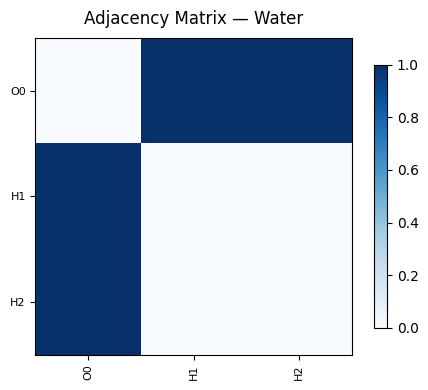

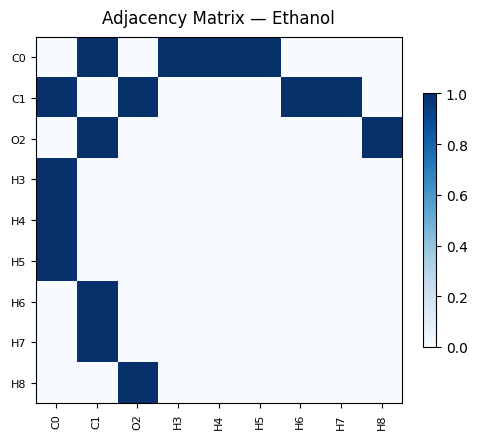

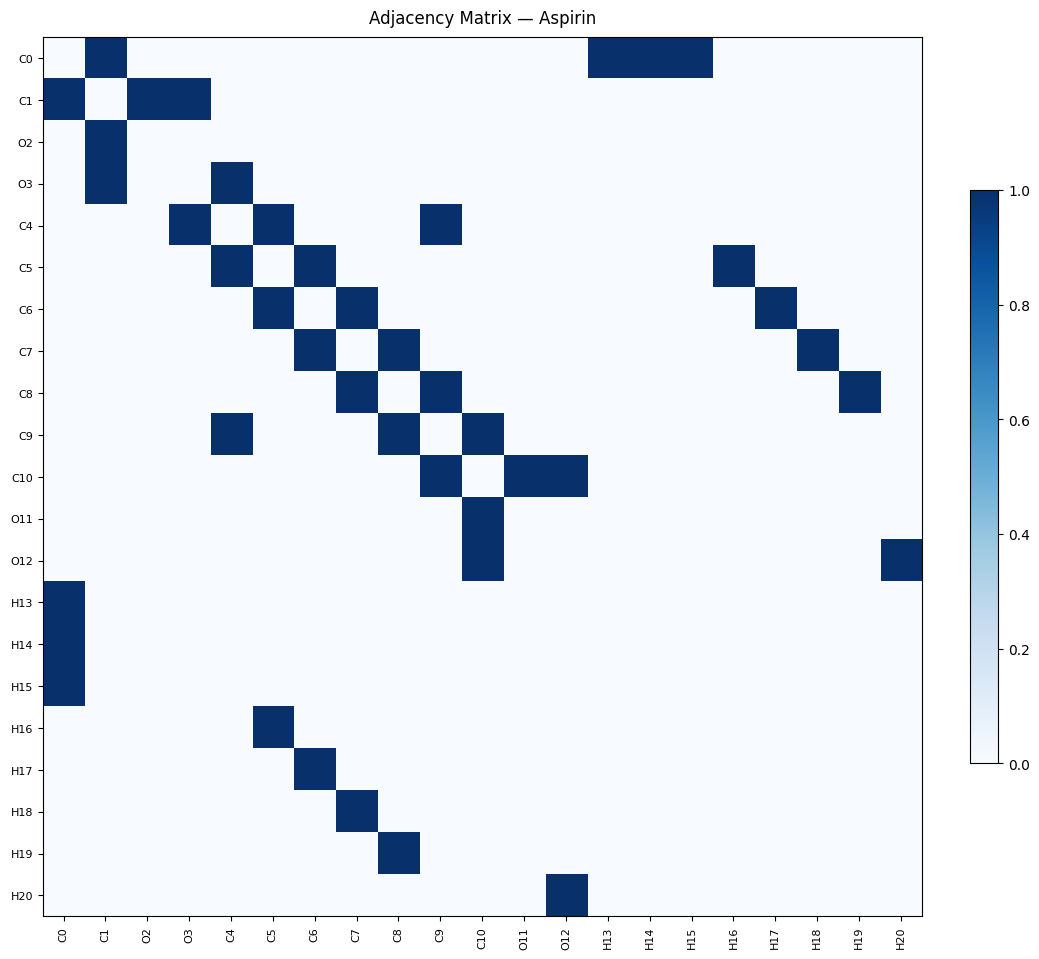

In [77]:
# ─────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────

MOLECULES = {
    "Water": "O",
    "Ethanol": "CCO",
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
}

for name, smiles in MOLECULES.items():
    describe_graph(name, smiles)

for name, smiles in MOLECULES.items():
    visualize_adjacency(name, smiles)